In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
#reading the data

df = pd.read_csv(r'downloads/insurance.csv')

In [41]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
df.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


In [5]:
df.shape   #seeing the shape of data

(1338, 7)

In [6]:
df.columns   #printing the column names 

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.info()   #info about our data and the data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()  #describing the numerical columns

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()    #inspecting for nulls

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.duplicated().any()    # checking for duplicates

True

In [11]:
df.duplicated().sum()     #found duplicated

1

In [12]:
duplicates = df[df.duplicated()]      #print the duplicate rows

duplicates

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [13]:
df = df.drop_duplicates()  #droping the duplicate row from the dataset

In [14]:
df.shape      #validating wether the duplicate row was droped or not

(1337, 7)

for i in df.columns:
    print(i , len(df[i].unique()))    #finding how many unique values are there in each columns

In [16]:
catergorical_columns = ['smoker', 'region', 'sex']          #defining the categorical colmns in our dataset


for i in df[catergorical_columns]:
    print(df[i].value_counts())                         #printing the value counts for categrical columns 

smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
sex
male      675
female    662
Name: count, dtype: int64


INSPECTING THIS WE CAN SEE THAT THERE ARE 1063 NON SMOKERS AND 274 SMOKERS IN OUR DATASAET.
AND ALSO THE GENDER DISTRIBUTION IN OUR DATASET IS EUQUALLY DUSTRIBUTED.
Similar is with the case of region.

In [18]:
df.dtypes.unique()     #unique datatypes in our dataset

array([dtype('int64'), dtype('O'), dtype('float64')], dtype=object)

In [19]:
group_by_datatypes = df.columns.to_series().groupby(by = df.dtypes).groups      #which column belong to which datatype

group_by_datatypes

{int64: ['age', 'children'], float64: ['bmi', 'charges'], object: ['sex', 'smoker', 'region']}

In [20]:
groupd_Df = pd.DataFrame(list(group_by_datatypes.values()), index = group_by_datatypes.keys(), columns = ['attr1', 'attr2', 'attr3'])

In [21]:
groupd_Df

,attr1,attr2,attr3
int64,age,children,None
float64,bmi,charges,None
object,sex,smoker,region


##### now we can see that which column belong to which data type in a more structured way 

In [23]:
df['children'].value_counts()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [24]:
#### lets create a function to study our numerical column in details with visualizations
def summary(x):
    min = df[x].min()
    max = df[x].max()
    q1 = df[x].quantile(0.25)
    q2 = df[x].quantile(0.50)
    q3 = df[x].quantile(0.75)
    print(f' 5 point summary of {x.capitalize()}')
    print(f' the min of {x.capitalize()} is {min}')
    print(f' the max  of {x.capitalize()} is {max}')
    print(f' the Q1 of {x.capitalize()} is {q1}')
    print(f' the Q2(median) of {x.capitalize()} is {q2}')
    print(f' the Q3 {x.capitalize()} is {q3}')

    plt.figure(figsize = (10,8))
    plt.subplot(1,1,1)
    sns.histplot(df[x], kde = True, color = 'r')
    plt.title(f'{x.capitalize()} Density Distribution')
    plt.show()

    plt.figure(figsize = (10,8))
    plt.subplot(1,1,1)
    sns.violinplot(x = df[x])
    plt.title(f'{x.capitalize()} violin Plot')
    plt.show()

    plt.figure(figsize = (10,8))
    plt.subplot(1,1,1)
    sns.boxplot( x = df[x])
    plt.title(f'{x.capitalize()} Box plot')
    plt.show

    plt.figure(figsize = (10,8))
    plt.subplot(1,1,1)
    sns.kdeplot(df[x], cumulative = True)
    plt.title(f'{x.capitalize()} Cumulative Density Distribution')
    plt.show()


 5 point summary of Bmi
 the min of Bmi is 15.96
 the max  of Bmi is 53.13
 the Q1 of Bmi is 26.29
 the Q2(median) of Bmi is 30.4
 the Q3 Bmi is 34.7


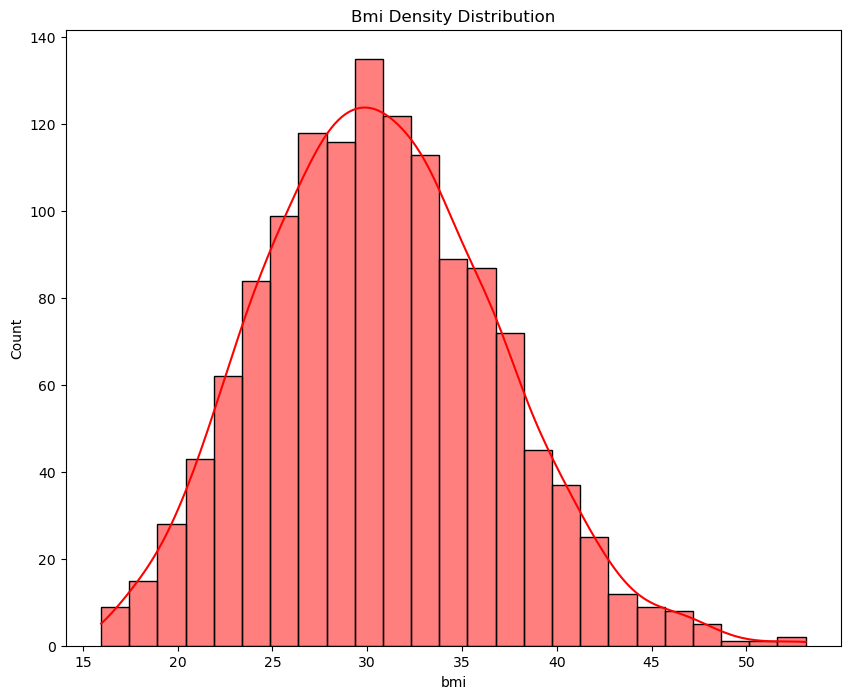

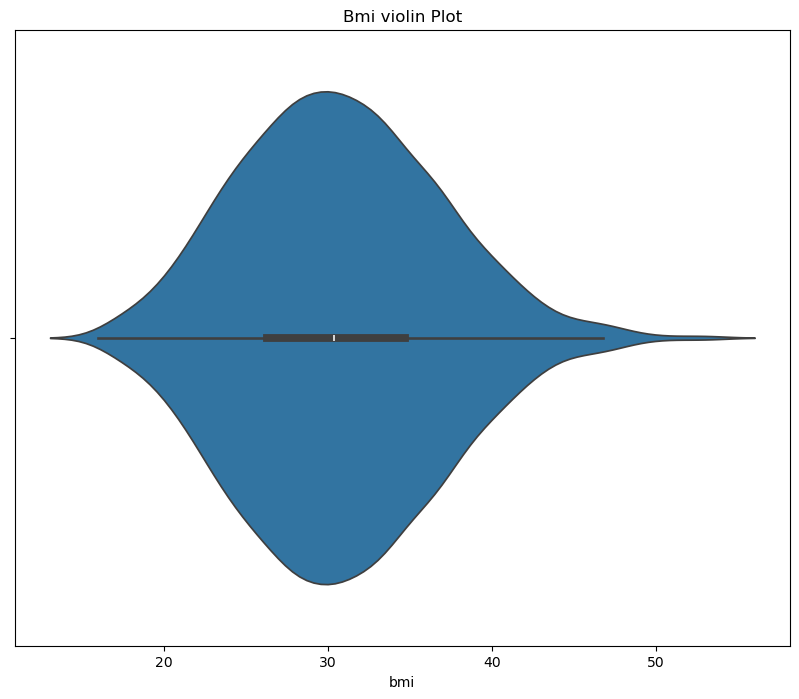

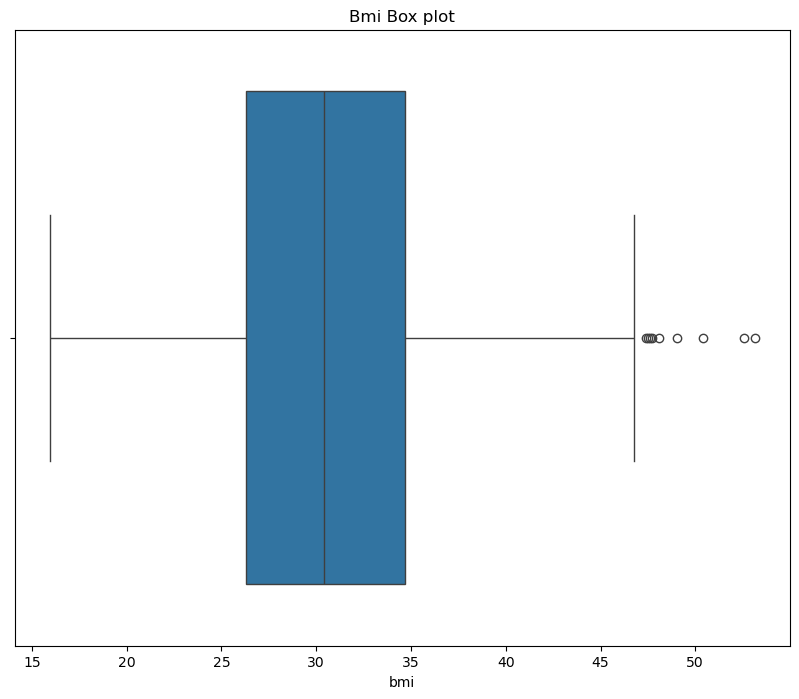

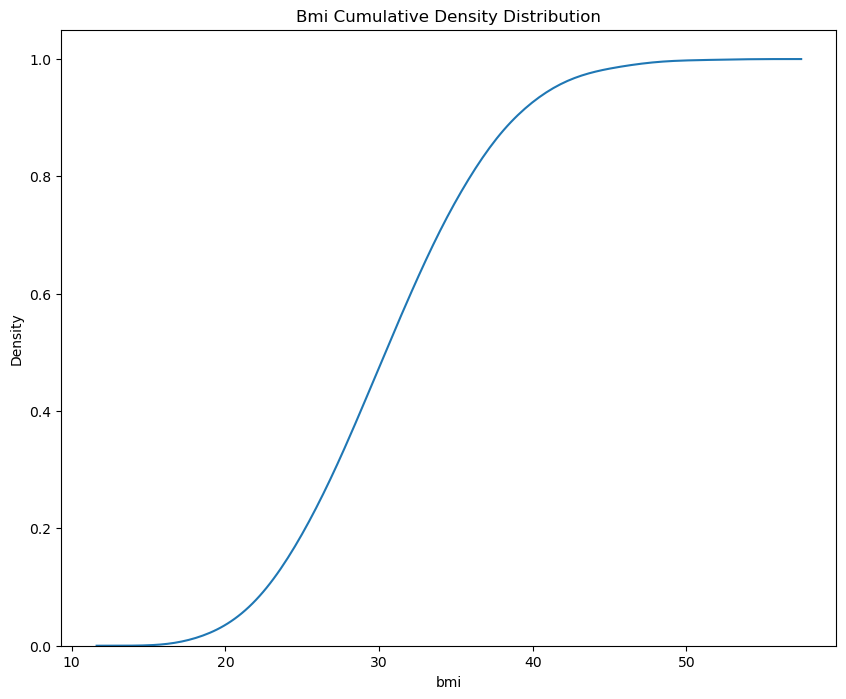

In [25]:
summary('bmi')

In [26]:
#lets do a deep dive in box plot

def box(data, x):
    plt.figure(figsize =(10,8))
    data.boxplot([x])

    mean =data[x].mean()
    median = data[x].median()
    q1 = data[x].quantile(0.25)
    q3 = data[x].quantile(0.75)
    iqr = q3-q1
    upperbound = q3 + 1.5 * iqr
    lowerbound = q1 - 1.5 * iqr  
    
    outliers = df[x][(df[x] > upperbound) | (df[x]< lowerbound)]
    num_outliers = outliers.count()

    
    print(f' the mean of {x.capitalize()} is {mean}')
    print(f' the median  of {x.capitalize()} is {median}')
    print(f' the Q1 of {x.capitalize()} is {q1}')
    print(f' the Q3 {x.capitalize()} is {q3}')
    print(f' the upperbound of {x.capitalize()} is {upperbound}')
    print(f' the lowerbound of {x.capitalize()} is {lowerbound}')
    print(f'number of outliers :-  {num_outliers}')
    
    plt.hlines(mean, 0.8, 1.2, colors = 'red', linestyles = 'dashed', label = 'Mean')
    plt.hlines(median, 0.85, 1.25 , color = 'green', linestyles = 'dashed', label = 'median')
    plt.hlines(q1 , 0.85, 1.3, color = 'blue', linestyles = 'dashed', label = 'q1')
    plt.hlines(q3, 0.85, 1.3, color = 'blue',linestyles = 'dashed', label = 'q3')
    plt.hlines(upperbound, 0.85, 1.3, color = 'orange',linestyles = 'dashed', label = 'upperbound')
    plt.hlines(lowerbound, 0.85, 1.3, color = 'orange',linestyles = 'dashed', label = 'lowerbound')
    plt.legend()

 the mean of Bmi is 30.66345175766642
 the median  of Bmi is 30.4
 the Q1 of Bmi is 26.29
 the Q3 Bmi is 34.7
 the upperbound of Bmi is 47.31500000000001
 the lowerbound of Bmi is 13.674999999999994
number of outliers :-  9


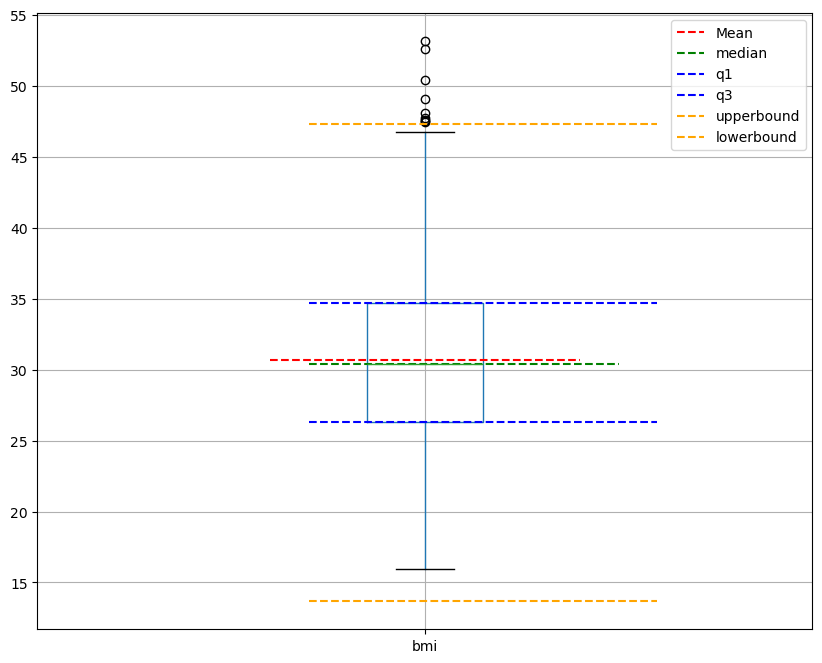

In [27]:
box(df, 'bmi')

In [96]:
## lets find some insights in our data
#lets Find how many people have the been insured with a particular age


def age_analysis(age_val):
    df1 = df[df['age'] == age_val]
    print(f' total number of people who have insured for age {age_val} are {len(df1)}')
    print(df1)

In [98]:
age_analysis(64)

 total number of people who have insured for age 64 are 22
      age     sex     bmi  children smoker     region      charges
62     64    male  24.700         1     no  northwest  30166.61817
94     64  female  31.300         2    yes  southwest  47291.05500
199    64  female  39.330         0     no  northeast  14901.51670
328    64  female  33.800         1    yes  southwest  47928.03000
335    64    male  34.500         0     no  southwest  13822.80300
378    64  female  30.115         3     no  northwest  16455.70785
398    64    male  25.600         2     no  southwest  14988.43200
402    64  female  32.965         0     no  northwest  14692.66935
418    64    male  39.160         1     no  southeast  14418.28040
420    64    male  33.880         0    yes  southeast  46889.26120
534    64    male  40.480         0     no  southeast  13831.11520
603    64  female  39.050         3     no  southeast  16085.12750
635    64    male  38.190         0     no  northeast  14410.93210
664

In [100]:
## lets do some analysis on Categorical columns

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [114]:
grp = df.columns.to_series().groupby(by = df.dtypes).groups

In [162]:
grp

l=[]
for key,values in grp.items():
    if key == 'object':
        l.extend(values)
print(l)

['sex', 'smoker', 'region']


In [164]:
for col in l:
    print(col)

sex
smoker
region


In [292]:
    def catergorical_analysis(x, y, z):
        a = df[x].value_counts()
        b = df[x].unique()
        print(f' Unique Values in col "{x}" are {b}')
        print(f' Value count in col "{x}" are {a}')
    
    
        plt.figure(figsize = (5,5))
        ax = sns.countplot(data = df, x = x)
        ax.bar_label(ax.containers[0])
        plt.show()
    
        
        plt.figure(figsize = (5,5))
        ax = sns.countplot(data = df, x = x, hue = y)
        [ax.bar_label(container) for container in ax.containers]
        plt.show()
    
    
        plt.figure(figsize = (5,5))
        ax = sns.countplot(data = df, x = x, hue = z)
        [ax.bar_label(container) for container in ax.containers]
        plt.show()



 Unique Values in col "sex" are ['female' 'male']
 Value count in col "sex" are sex
male      675
female    662
Name: count, dtype: int64


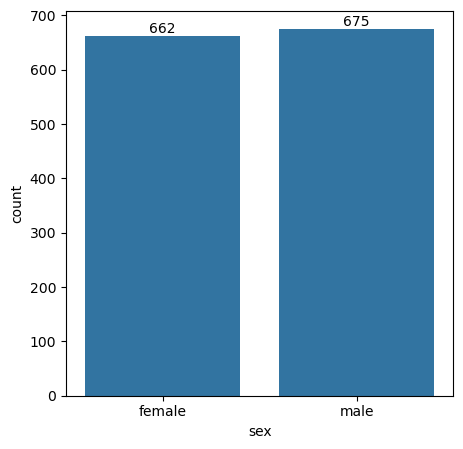

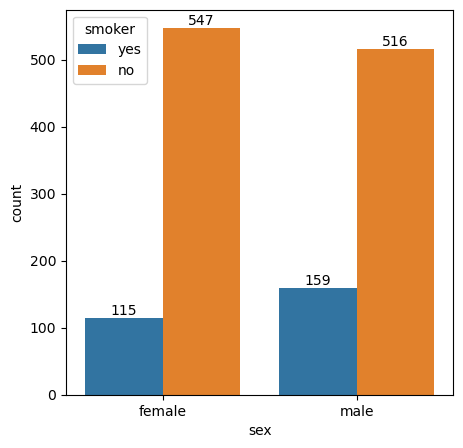

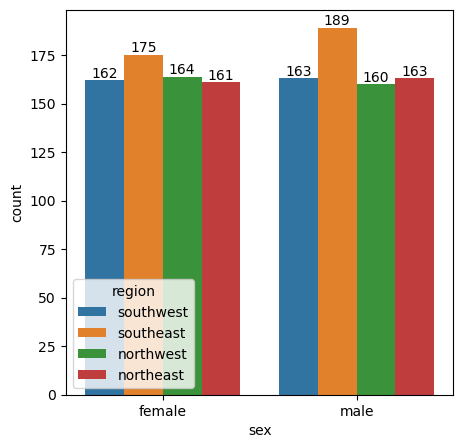

In [294]:
catergorical_analysis('sex', 'smoker', 'region')

 Unique Values in col "smoker" are ['yes' 'no']
 Value count in col "smoker" are smoker
no     1063
yes     274
Name: count, dtype: int64


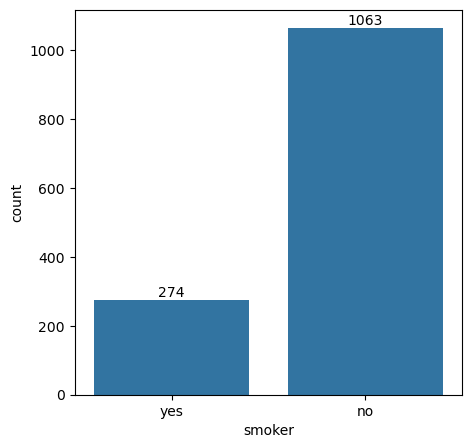

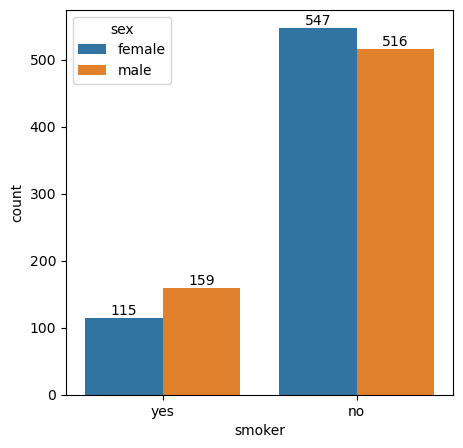

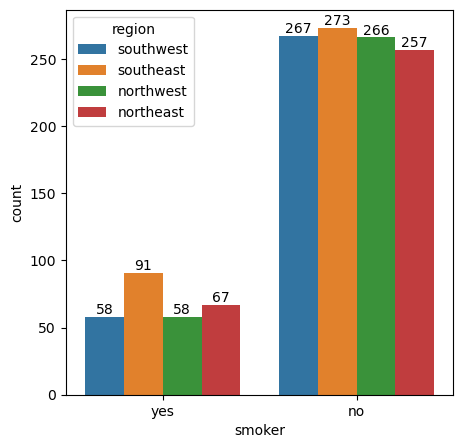

In [296]:
catergorical_analysis('smoker', 'sex', 'region')

 Unique Values in col "region" are ['southwest' 'southeast' 'northwest' 'northeast']
 Value count in col "region" are region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


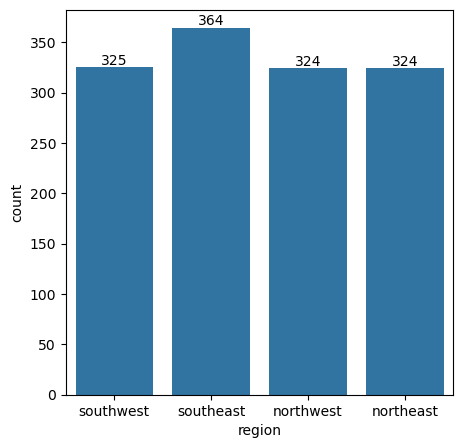

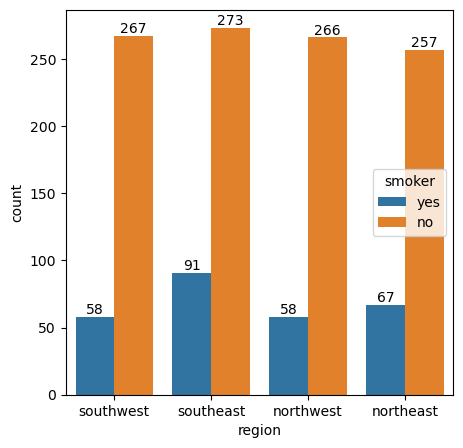

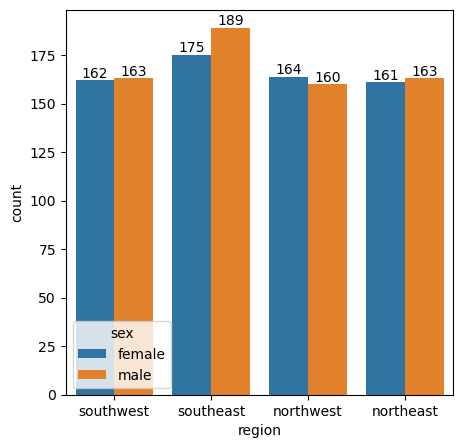

In [298]:
catergorical_analysis('region', 'smoker', 'sex')

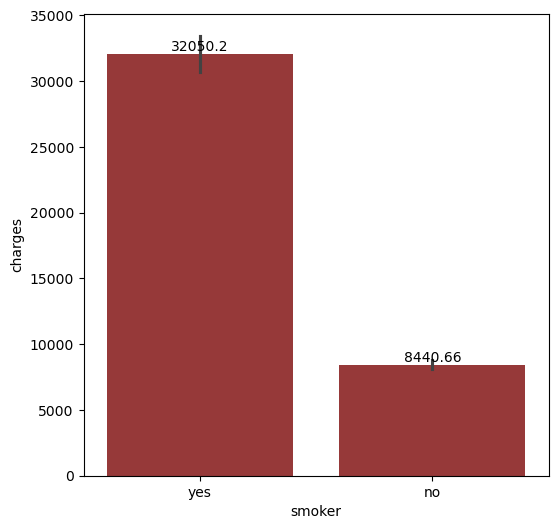

In [320]:
##lets see how does charges vary based on Smokers/nonsmokers
### this shows what is the the average charges for both smoker and non-smoker


plt.figure(figsize = (6, 6))
ax = sns.barplot(data = df, x = 'smoker', y = 'charges', color = 'brown')
ax.bar_label(ax.containers[0])
plt.show()

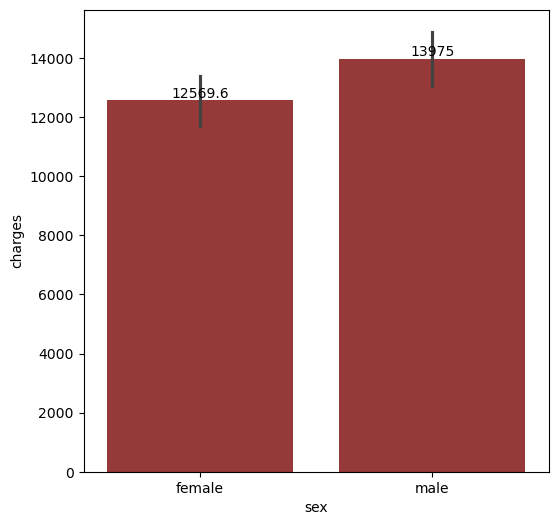

In [322]:

plt.figure(figsize = (6, 6))
ax = sns.barplot(data = df, x = 'sex', y = 'charges', color = 'brown')
ax.bar_label(ax.containers[0])
plt.show()

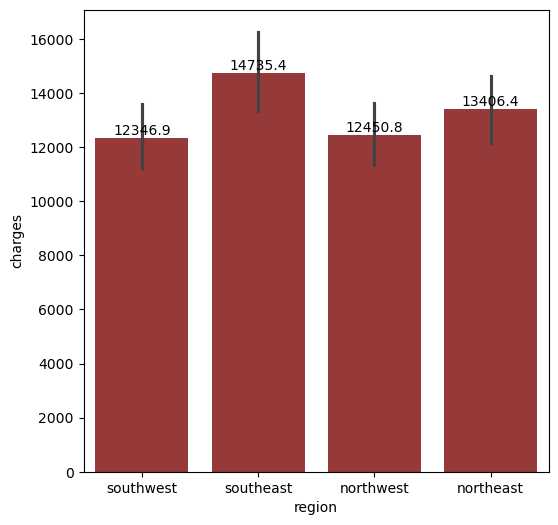

In [328]:



plt.figure(figsize = (6, 6))
ax = sns.barplot(data = df, x = 'region', y = 'charges', color = 'brown')
ax.bar_label(ax.containers[0])
plt.show()

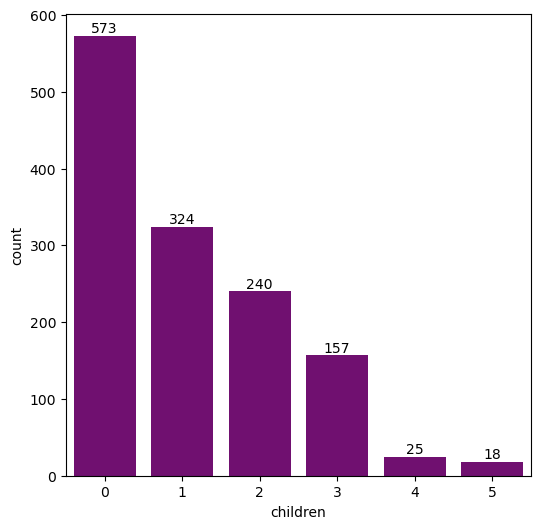

In [330]:


plt.figure(figsize = (6, 6))
ax = sns.countplot(data = df, x = 'children', color = 'purple')
ax.bar_label(ax.containers[0])
plt.show()

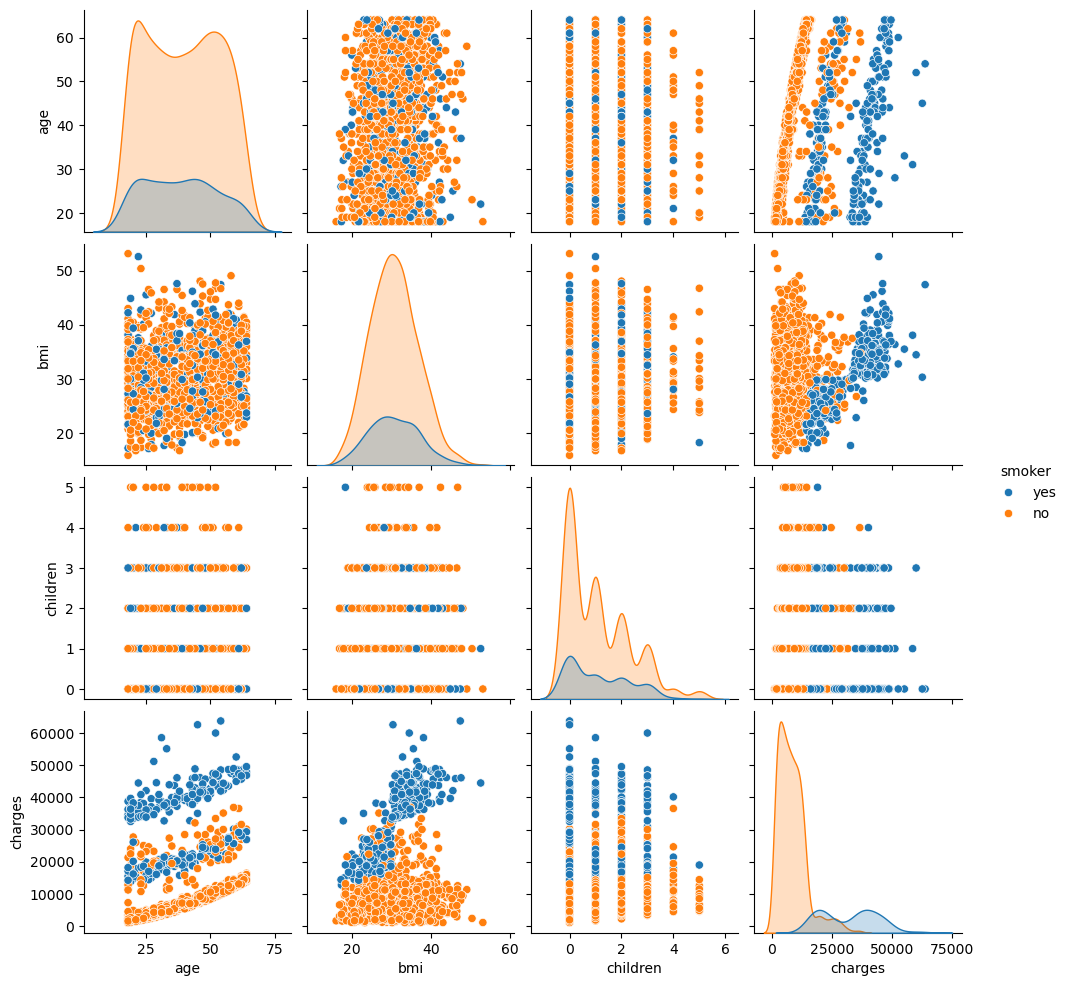

In [332]:
## lets find how each column is realted to each other with the help of pairplot


sns.pairplot(data = df, hue = 'smoker')

In [43]:
### converting categorical columns into dummy variables

df['sex'] = np.where(df['sex'] == 'male', 1, 0)

In [47]:
df['smoker'] = np.where(df['smoker'] == 'yes' , 1,0)

In [49]:
#dropping the region column

df1 = df.drop('region', axis = 1)

<Axes: >

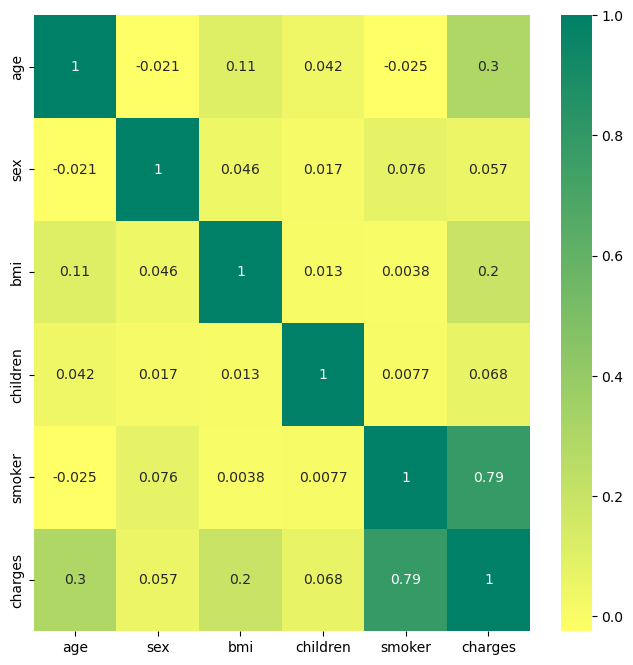

In [51]:
### based on this lets study the correlation between each attribute in our dataset


correlation = df1.corr()
plt.figure(figsize= (8, 8))
sns.heatmap(correlation, annot = True, cmap = 'summer_r')

# 4. Hypothesis Testing:

 A Statistical Hypothesis Test is a method of statistical inference which is used in making decisions using sample data. Here we attempt to answer a few questions based on the nature of distribution and relationships between various attributes in our dataset through Hypothesis Tests. We follow the following methodology:

1. Formulate the null hypothesis and the alternative hypothesis.
2. Select an appropriate statistical test and the corresponding test statistic.
3. Choose level of significance α (generally taken as 0.05).
4. Collect data and calculate the value of test statistic.
5. Determine the probability associated with the test statistic under the null hypothesis using sampling distribution of the test statistic
6. Compare the probability associated with the test statistic with level of significance specified

### 4.1 Do charges of people who smoke differ significantly from the people who don't?

#### 4.1.1. Step 1: State the null and alternative hypothesis

* $H_0$: $\mu_s$ = $\mu_n$ 
* $H_A$: $\mu_s$ != $\mu_n$

Where:
 - $\mu_s$ = Mean Charge of all smokers in our data
 - $\mu_n$ = Mean Charge of all non - smokers in our data

#### 4.1.2. Step 2: Select an appropriate statistical test and the corresponding test statistic
We select a 2-sample t-test as our statistical test and the corresponding t statistic as our test statistic.

#### 4.1.3. Step 3: Choose level of significance α
We select α = 0.05

#### 4.1.4. Step 4: Collect data and calculate the value of test statistic

In [61]:
smokers = df[df['smoker'] == 1]
non_smokers = df[df['smoker'] == 0]

charges_smokers = smokers['charges']
charges_non_smokers = non_smokers['charges']

In [77]:
print(f' Number of smokers {smokers.shape[0]}')
print(f' variance in charges_smokers {np.var(charges_smokers)}')
print(f' number of non smokers {non_smokers.shape[0]}')
print(f' variance in charges in non smokers {np.var(charges_non_smokers)}')

 Number of smokers 274
 variance in charges_smokers 132721153.13625304
 number of non smokers 1064
 variance in charges in non smokers 35891656.00316425


/var/folders/2d/gd1dhxgj3zn8xwpcnhj9q2180000gn/T/ipykernel_28146/3925100267.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels)


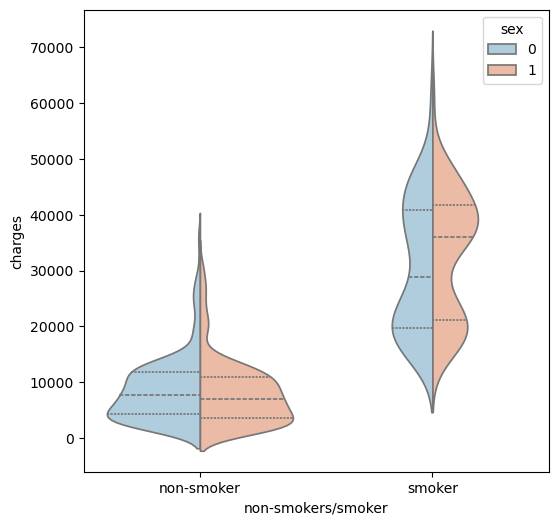

In [140]:
plt.figure(figsize = (6,6))
ax= sns.violinplot(x = 'smoker', y = 'charges', hue = 'sex', data = df, palette="RdBu_r",split = True, inner="quartiles", legend= True)
plt.xlabel('non-smokers/smokers')

xlabels = ['non-smoker', 'smoker']
ax.set_xticklabels(xlabels)
plt.show()

In [81]:
from scipy.stats import ttest_ind

t_statistics , p_value = ttest_ind(charges_smokers, charges_non_smokers, equal_var = False)

In [83]:
t_statistics , p_value 

(32.751887766341824, 5.88946444671698e-103)

#### 4.1.5. Step 5: Determine the probability associated with the test statistic under the null hypothesis using sampling distribution of the test statistic

In [86]:
print ("two-sample t-test p-value=", p_value)

two-sample t-test p-value= 5.88946444671698e-103


#### 4.1.6. Step 6: Compare the probability associated with the test statistic with level of significance specified
##### At 5% significance level, α = 0.05

In [88]:
p_value > 0.005   ## significance value

False

### 4.1.7. Conclusion:
- We <b>Reject</b> the Null Hypothesis and state that <b>At 5% significance level<b/>, the mean charges of smokers and non - smokers are <b>not equal<b/>.
- Hence, charges of people who smoke indeed differ significantly from the people who don't.

### 4.2. Does BMI of males differ significantly from that of females?

#### 4.2.1. Step 1: State the null and alternative hypothesis
* $H_0$: $\mu_m$ = $\mu_f$ 
* $H_A$: $\mu_m$ != $\mu_f$

Where:
 - $\mu_m$ = Mean BMI of all male insured in our data
 - $\mu_f$ = Mean BMI of all female insured in our data

#### 4.2.2. Step 2: Select an appropriate statistical test and the corresponding test statistic
We select a 2-sample t-test as our statistical test and the corresponding t statistic as our test statistic.
#### 4.2.3. Step 3: Choose level of significance α
We select α = 0.05
#### 4.2.4. Step 4: Collect data and calculate the value of test statistic

In [152]:
males = df[df['sex'] == 1]
females = df[df['sex'] == 0]

bmi_males = males['bmi']
bmi_females = females['bmi'] 


In [182]:
print(f' Number oF males {males.shape[0]}')
print(f' Variance of bmi_males {np.var(bmi_males)}')
print(f' Number of females {females.shape[0]}')
print(f' Variance of bmi_females {np.var(bmi_females)}')

 Number oF males 676
 Variance of bmi_males 37.6491607363954
 Number of females 662
 Variance of bmi_females 36.49917703379856


/var/folders/2d/gd1dhxgj3zn8xwpcnhj9q2180000gn/T/ipykernel_28146/4282115388.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels)


<function matplotlib.pyplot.show(close=None, block=None)>

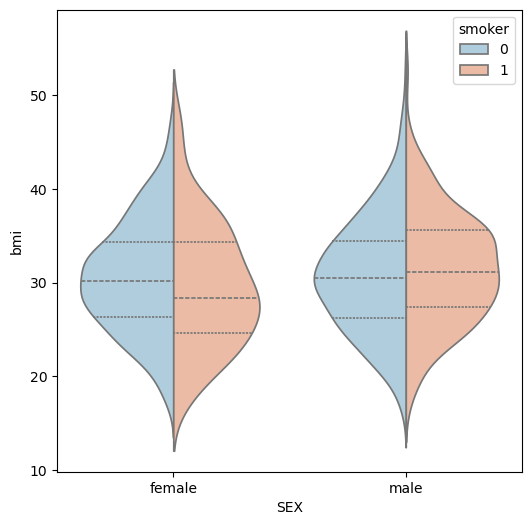

In [206]:
plt.figure(figsize = (6,6))
ax = sns.violinplot(x = 'sex', y = 'bmi', data = df, palette = "RdBu_r", split = True, hue = 'smoker', inner = 'quartile')

plt.xlabel('SEX')
xlabels= ['female', 'male']
ax.set_xticklabels(xlabels)
plt.show

In [168]:
from scipy.stats import ttest_ind

t_statistics , p_value= ttest_ind(bmi_males, bmi_females, equal_var = False)

#### 4.1.5. Step 5: Determine the probability associated with the test statistic under the null hypothesis using sampling distribution of the test statistic

In [170]:
t_statistics , p_value

(1.697027933124022, 0.08992430667834876)

#### 4.1.6. Step 6: Compare the probability associated with the test statistic with level of significance specified
##### At 5% significance level, α = 0.05

In [208]:
p_value > 0.05

True

### 4.2.7. Conclusion: 
 - We <b>Fail to Reject</b> the Null Hypothesis and state that <b>At 5% significance level, the mean BMI of insured males and females are equal</b>.
 - Hence, BMI of males do not differ significantly from that of females in our data.